#### Import and Initialize Earth Engine

In [1]:
import ee

In [14]:
ee.Authenticate()
ee.Initialize(project="ee-krle4401")

#### Bring in SAR Imagery from the Sentinel Mission. Define the region of interest and time of interest

In [7]:
import datetime

def monthly_mean(year, month):
    start = ee.Date.fromYMD(year, month, 1)
    end = start.advance(1, 'month')
    filtered = s1.filterDate(start, end)
    return filtered.mean().set('month', month).set('system:time_start', start.millis())

months = [monthly_mean(2021, m) for m in range(1, 13)]
monthly_collection = ee.ImageCollection(months)


In [17]:
import geemap

# Define Area of Interest (AOI)
aoi = ee.Geometry.Point([31.5, -24.0]).buffer(10000)   # Kruger NP as example

# Load Sentinel-1 VV collection (filtered)
collection = ee.ImageCollection('COPERNICUS/S1_GRD') \
    .filterBounds(aoi) \
    .filterDate('2021-01-01', '2021-06-30') \
    .filter(ee.Filter.eq('instrumentMode', 'IW')) \
    .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV')) \
    .select('VV') \
    .sort('system:time_start') \
    .limit(10)  # Adjust this as needed

# Create a map
Map = geemap.Map(center=[-24.0, 31.5], zoom=10)
Map.addLayer(aoi, {'color': 'red'}, 'ROI')

# Loop through the collection and add each image as a layer
image_list = collection.toList(collection.size())

for i in range(collection.size().getInfo()):
    image = ee.Image(image_list.get(i))
    date = image.date().format('YYYY-MM-dd').getInfo()
    vis_params = {'min': -25, 'max': 0, 'palette': ['blue', 'white', 'green']}
    Map.addLayer(image.clip(aoi), vis_params, f'S1 VV {date}')

# Display the map in notebook
Map


Map(center=[-24.0, 31.5], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI…

In [23]:
import datetime

def monthly_mean(year, month):
    start = ee.Date.fromYMD(year, month, 1)
    end = start.advance(1, 'month')
    filtered = s1.filterDate(start, end)
    return filtered.mean().set('month', month).set('system:time_start', start.millis())

months = [monthly_mean(2021, m) for m in range(1, 13)]
monthly_collection = ee.ImageCollection(months)

In [24]:
def extract_backscatter(image):
    stat = image.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=aoi,
        scale=10,
        maxPixels=1e9
    )
    return ee.Feature(None, {
        'date': image.date().format('YYYY-MM'),
        'backscatter': stat.get('VV')
    })

features = ee.FeatureCollection(monthly_collection.map(extract_backscatter))


In [29]:
import geemap
import pandas as pd

df = geemap.ee_to_gdf(features)
df_pd = df.drop(columns='geometry')  # remove the geometry
df_pd['date'] = pd.to_datetime(df_pd['date'])  # ensure proper datetime format
df_pd = df_pd.sort_values('date')  # sort just in case

df_pd.to_csv("sentinel1_monthly_backscatter.csv", index=False)



#### Plot VV Backscatter (Seasonal Time Series)

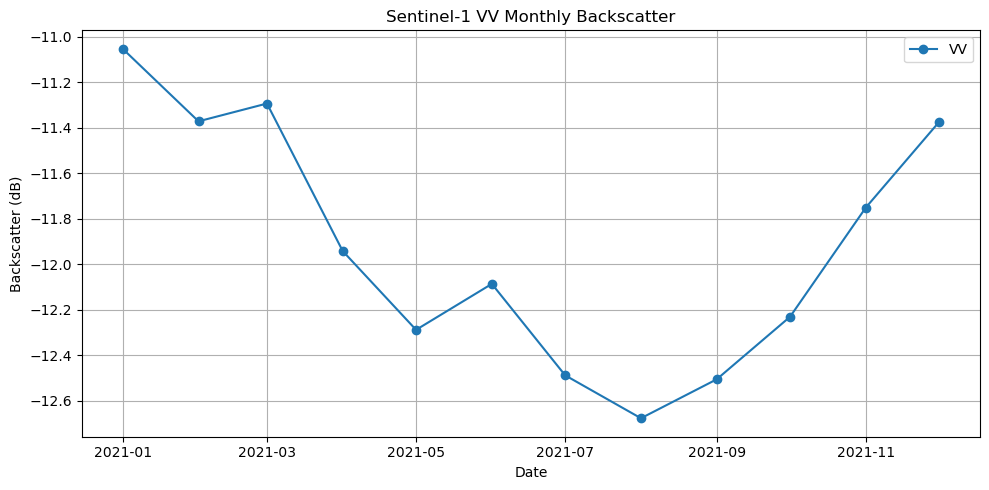

In [30]:
import matplotlib.pyplot as plt
import pandas as pd

df_pd['date'] = pd.to_datetime(df_pd['date'])
df_pd = df_pd.sort_values('date')

plt.figure(figsize=(10, 5))
plt.plot(df_pd['date'], df_pd['backscatter'], marker='o', label='VV')
plt.title('Sentinel-1 VV Monthly Backscatter')
plt.xlabel('Date')
plt.ylabel('Backscatter (dB)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


#### Add VH and VV/VH Ratio

In [ ]:
def monthly_mean(year, month):
    start = ee.Date.fromYMD(year, month, 1)
    end = start.advance(1, 'month')
    filtered = s1.filterDate(start, end)
    return filtered.mean().set({
        'month': month,
        'system:time_start': start.millis()
    })


#### Get both VV and VH collections

In [34]:
from tqdm import tqdm

# VV and VH ImageCollection
s1 = ee.ImageCollection('COPERNICUS/S1_GRD') \
    .filterBounds(aoi) \
    .filter(ee.Filter.eq('instrumentMode', 'IW')) \
    .filterDate('2019-01-01', '2023-12-31') \
    .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV')) \
    .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VH'))

# Generate monthly mean images
def monthly_mean(year, month):
    start = ee.Date.fromYMD(year, month, 1)
    end = start.advance(1, 'month')
    filtered = s1.filterDate(start, end)
    return filtered.mean().set({'year': year, 'month': month, 'system:time_start': start.millis()})

monthly_images = [monthly_mean(y, m) for y in range(2019, 2024) for m in range(1, 13)]

# Safely reduce each image one at a time
records = []

for img in tqdm(monthly_images, desc="Processing monthly VV/VH"):
    date_str = img.date().format('YYYY-MM').getInfo()
    stats = img.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=aoi,
        scale=10,
        maxPixels=1e9
    ).getInfo()
    
    try:
        vv = stats.get('VV')
        vh = stats.get('VH')
        if vv is not None and vh is not None:
            ratio = vv - vh
            records.append({'date': date_str, 'VV': vv, 'VH': vh, 'VVVH_ratio': ratio})
    except Exception as e:
        print(f"⚠️ Error on {date_str}: {e}")

# Convert to DataFrame
df = pd.DataFrame(records)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

Processing monthly VV/VH: 100%|██████████| 60/60 [06:07<00:00,  6.13s/it]


#### Plot VV, VH, and VV/VH Ratio

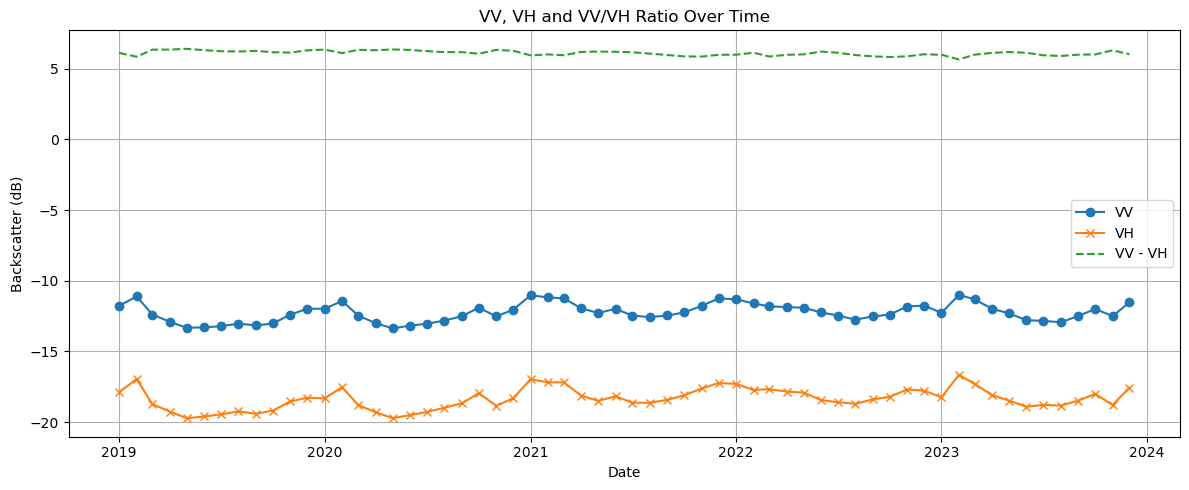

In [35]:
plt.figure(figsize=(12, 5))
plt.plot(df['date'], df['VV'], label='VV', marker='o')
plt.plot(df['date'], df['VH'], label='VH', marker='x')
plt.plot(df['date'], df['VVVH_ratio'], label='VV - VH', linestyle='--')
plt.title('VV, VH and VV/VH Ratio Over Time')
plt.xlabel('Date')
plt.ylabel('Backscatter (dB)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


#### Monthly Anomaly (deviation from mean)

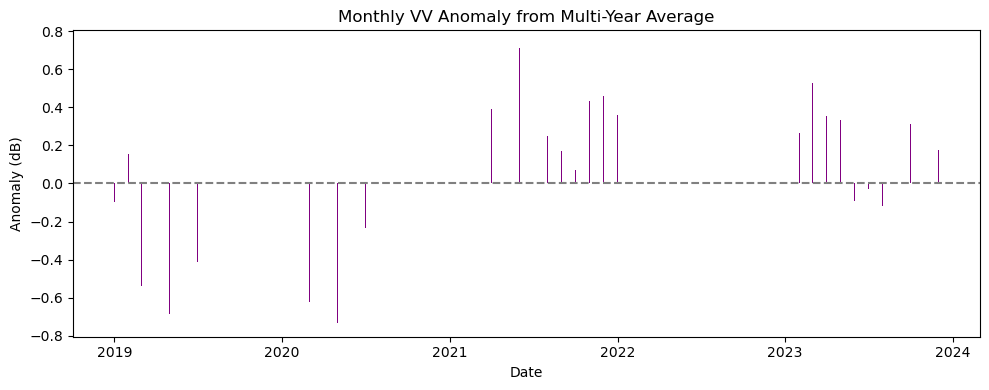

In [36]:
df['month'] = df['date'].dt.month
monthly_mean = df.groupby('month')['VV'].mean().rename('monthly_mean')
df = df.join(monthly_mean, on='month')
df['VV_anomaly'] = df['VV'] - df['monthly_mean']

# Plot anomaly
plt.figure(figsize=(10, 4))
plt.bar(df['date'], df['VV_anomaly'], color='purple')
plt.axhline(0, color='gray', linestyle='--')
plt.title('Monthly VV Anomaly from Multi-Year Average')
plt.xlabel('Date')
plt.ylabel('Anomaly (dB)')
plt.tight_layout()
plt.show()


#### Map Monthly SAR Images

In [41]:
Map = geemap.Map(center=[-24.0, 31.5], zoom=10)
Map.addLayer(aoi, {'color': 'red'}, 'AOI')

for img in monthly_images:
    try:
        date = img.date().format("YYYY-MM").getInfo()
        Map.addLayer(img.select('VV').clip(aoi), {'min': -25, 'max': 0}, f'VV {date}')
    except Exception as e:
        print(f"⚠️ Skipping image: {e}")

Map

Map.to_html("sentinel1_monthly_layers.html")


#### Compare Across Years (e.g., 2019–2023)

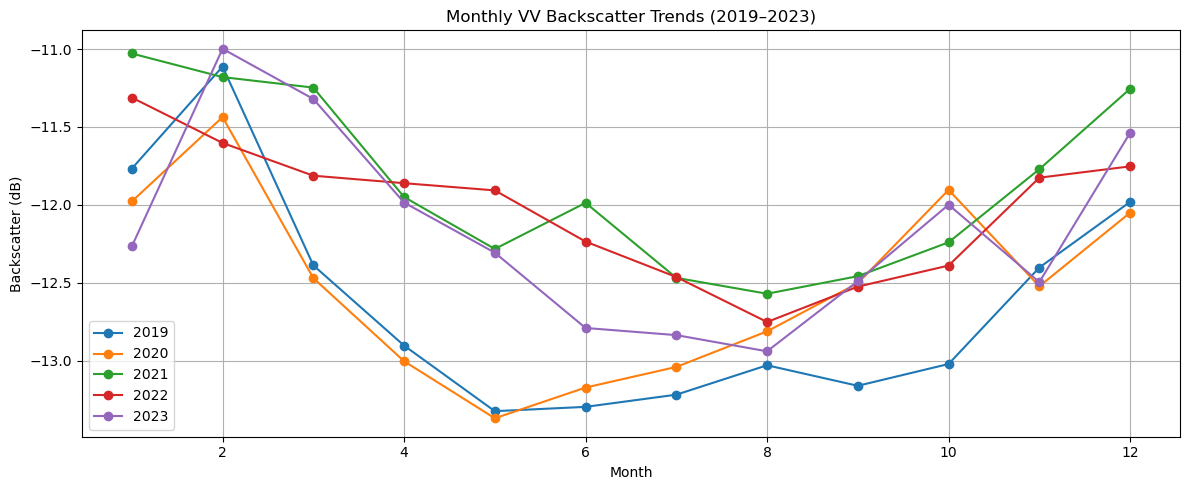

In [38]:
df['year'] = df['date'].dt.year

# Lineplot by month across years
plt.figure(figsize=(12, 5))
for yr in sorted(df['year'].unique()):
    subset = df[df['year'] == yr]
    plt.plot(subset['month'], subset['VV'], label=str(yr), marker='o')

plt.title('Monthly VV Backscatter Trends (2019–2023)')
plt.xlabel('Month')
plt.ylabel('Backscatter (dB)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
